# Computer Vision — Part 2 · Practical Notebook
## STUDENT VERSION — fill in every `TODO`

**Companion lab for the lecture: Classic Networks → ResNets → 1×1 Convs → Transfer Learning → Data Augmentation → Vision Transformers**

---

This notebook is deliberately **practical**. We focus on the workflows you will actually use in real projects and in industry:

- We **use pretrained models** from `torchvision` instead of re-implementing LeNet / AlexNet / VGG from scratch. Nobody trains these from zero anymore — you download weights.
- We do a **real transfer-learning fine-tune** on a real dataset. This is the single most common deep-learning-for-vision task in the wild.
- We build a **production-style `transforms` augmentation pipeline**.
- We **compare a CNN (ResNet) against a Vision Transformer (ViT)** and fine-tune both — the architecture family powering most modern systems.
- We then move to **CLIP**: zero-shot image classification with language, the contrastive loss behind it (built from scratch), and prompt engineering — the workflow behind image search and modern multimodal AI.

### How to use this notebook

Cells marked **`# TODO`** are yours to complete — that is where the learning happens. Each one gives you the surrounding structure, the expected output shape, and hints; you write the technique. Cells *without* a TODO (setup, dataset download, plotting helpers) are given to you complete — read them, run them, but you do not need to edit them.

Work top to bottom: later cells depend on variables and helpers defined earlier.

> **How to run this:** Easiest is Google Colab with a GPU (`Runtime → Change runtime type → GPU`). It also runs on a local machine with PyTorch installed; CPU works but the fine-tuning sections will be slow.


## 1 · Setup & device

We install (if needed) and import everything once. The `device` line is the
standard idiom: write code once, run on GPU if available, fall back to CPU.


In [2]:
# If running on Colab, torch & torchvision are already installed.
# Uncomment the next line if you are on a fresh local environment.
# !pip install torch torchvision matplotlib --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import models, transforms, datasets
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

# The standard device idiom — every real PyTorch project starts like this.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version :", torch.__version__)
print("Using device    :", device)
if device.type == "cuda":
    print("GPU             :", torch.cuda.get_device_name(0))


PyTorch version : 2.12.0+cu130
Using device    : cuda
GPU             : NVIDIA GeForce RTX 4070


## 2 · Activations — a 2-minute visual sanity check

> *Lecture recap:* an activation is a **non-linear, differentiable** function
> placed between layers. Non-linear so the network can't collapse into one
> linear layer; differentiable so backprop has gradients to flow.

In practice you rarely *implement* activations — you pick one. But you should
be able to *see* why some choices cause trouble:

- **ReLU** — the default. Cheap, no saturation on the positive side. Risk:
  *dying ReLU* (negative inputs → 0 gradient → neuron stops learning).
- **Leaky ReLU** — small slope for negatives, fixes dying ReLU.
- **Sigmoid / tanh** — saturate at the tails → *vanishing gradients*. Avoid in
  hidden layers; sigmoid still fine as a final layer for binary probability.

Let's just plot them and their gradients.


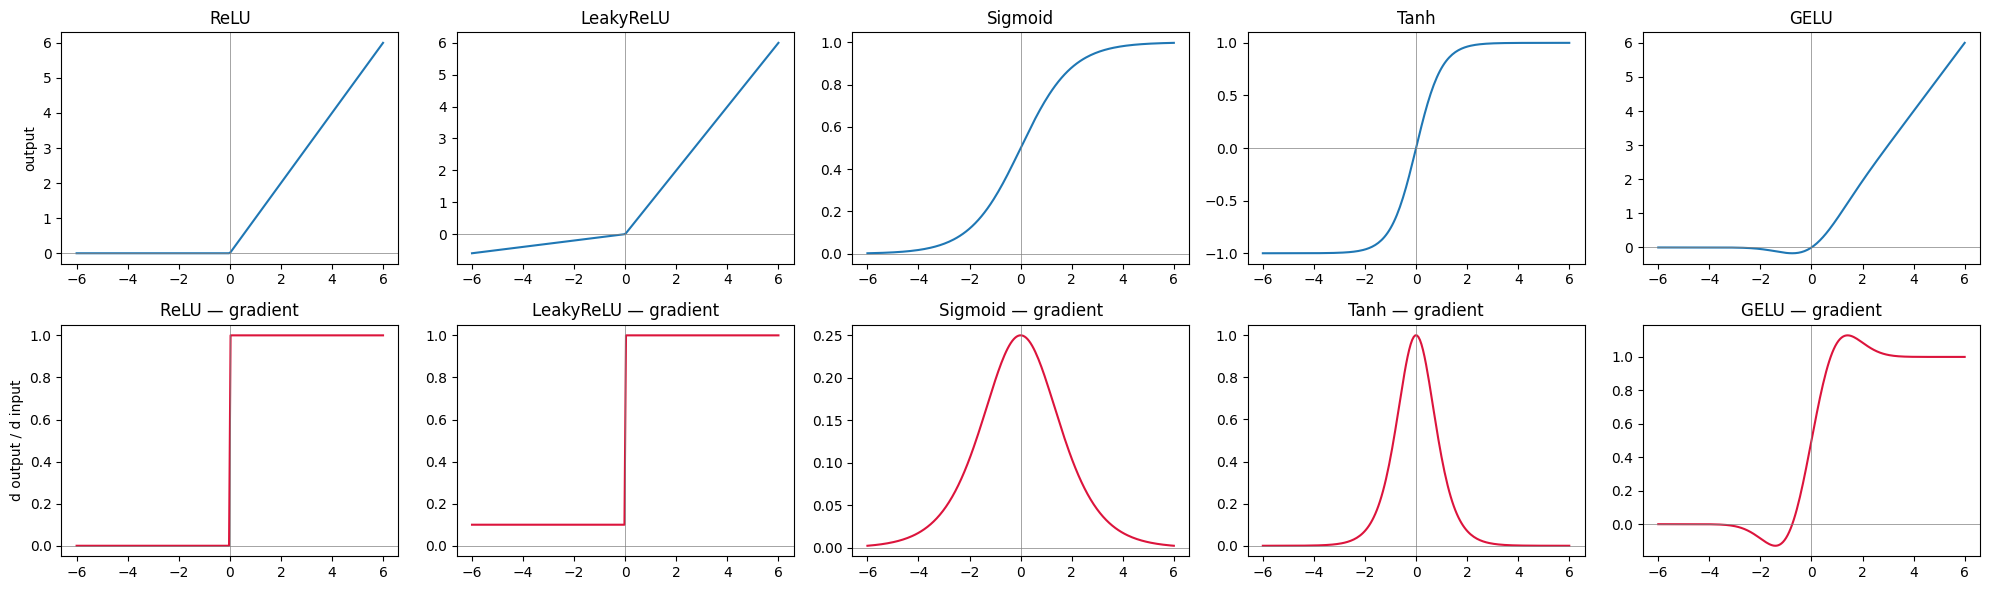

In [3]:
# TODO 2.1 -- Build the activation comparison.
#
# Fill in the `acts` dictionary so it maps each activation NAME to a
# callable that applies it. The plotting code below is given; it expects
# `acts` to contain exactly these four entries:
#
#   "ReLU"      -> F.relu
#   "LeakyReLU" -> leaky ReLU with negative_slope=0.1
#   "Sigmoid"   -> torch.sigmoid
#   "Tanh"      -> torch.tanh
#
# Hint: LeakyReLU needs an argument, so wrap it in a lambda:
#   lambda x: F.leaky_relu(x, negative_slope=0.1)
#
# Once it runs, ALSO add a fifth entry "GELU" -> F.gelu and re-run.
# GELU is the activation used inside Transformers / ViT (Section 8), so you
# will meet it again. In a comment below, describe in one sentence how GELU's
# gradient near z = 0 differs from ReLU's.

z = torch.linspace(-6, 6, 200, requires_grad=True)

acts = {
    "ReLU":      F.relu,
    "LeakyReLU": lambda x: F.leaky_relu(x, negative_slope=0.1),
    "Sigmoid":   F.sigmoid,
    "Tanh":      F.tanh,
    "GELU":      F.gelu,
}

# --- given: plotting (do not edit) ---
assert len(acts) >= 4, "Fill in the acts dictionary first."
fig, axes = plt.subplots(2, len(acts), figsize=(4 * len(acts), 6))
for col, (name, fn) in enumerate(acts.items()):
    y = fn(z)
    grad, = torch.autograd.grad(y.sum(), z, retain_graph=True)
    axes[0, col].plot(z.detach(), y.detach())
    axes[0, col].set_title(f"{name}")
    axes[0, col].axhline(0, color="gray", lw=.5); axes[0, col].axvline(0, color="gray", lw=.5)
    axes[1, col].plot(z.detach(), grad.detach(), color="crimson")
    axes[1, col].set_title(f"{name} — gradient")
    axes[1, col].axhline(0, color="gray", lw=.5); axes[1, col].axvline(0, color="gray", lw=.5)
axes[0, 0].set_ylabel("output"); axes[1, 0].set_ylabel("d output / d input")
plt.tight_layout(); plt.show()

# TODO: one sentence -- how does GELU's gradient near z = 0 differ from ReLU's?
# Your answer:
# GELU's gradient is smooth and non-zero near z = 0, whereas ReLU's gradient is zero for negative inputs and one for positive inputs.

**Read the bottom row — that's the row that matters for training.**
Notice the sigmoid and tanh gradients are nearly flat (≈0) once you move away from the centre. That flatness *is* the vanishing-gradient problem. ReLU's gradient is a clean 1 on the positive side — that is why it became the default.


## 3 · Convolution mechanics: shapes, stride, padding, pooling

> *Lecture recap:* a filter slides over the image computing dot products.
> **Stride** = step size (bigger stride → smaller output, less compute).
> **Padding** = a frame around the image so edge pixels get equal attention and
> (with the right padding) the output keeps the input's height/width — that's
> *"same"* padding. **Pooling** downsamples; max-pool keeps the most salient
> value in each window.

The single most useful practical skill here is **predicting output shapes**.
You will debug shape errors constantly. The formula for one spatial dimension:

$$ \text{out} = \left\lfloor \frac{\text{in} + 2p - k}{s} \right\rfloor + 1 $$

where `k` = kernel size, `s` = stride, `p` = padding.


In [4]:
# TODO 3.1a -- Implement the convolution output-size formula.
#
# For one spatial dimension:
#     out = floor( (in + 2*p - k) / s ) + 1
# where k = kernel size, s = stride, p = padding.
# Use integer floor division (//).

from matplotlib.pylab import floor


def conv_out(in_size, k, s, p):
    """Output spatial size of a conv/pool layer along one dimension."""
    # TODO: return the formula above
    out = ((in_size + (2*p) -k) // s) + 1 
    return out

# --- given: sanity-check the formula against PyTorch itself ---
x = torch.randn(1, 3, 32, 32)   # (batch, channels, H, W) -- a 32x32 RGB image

configs = [
    # (kernel, stride, padding, label)
    (3, 1, 1, "3x3, stride 1, pad 1  -> 'same' padding, size preserved"),
    (3, 1, 0, "3x3, stride 1, pad 0  -> 'valid' padding, shrinks by 2"),
    (3, 2, 1, "3x3, stride 2, pad 1  -> downsample by ~2 (used in ResNet)"),
    (5, 1, 2, "5x5, stride 1, pad 2  -> 'same' padding with a bigger kernel"),
]

print(f"{'config':52s} | formula | actual")
print("-" * 78)
for k, s, p, label in configs:
    layer = nn.Conv2d(3, 8, kernel_size=k, stride=s, padding=p)
    actual = layer(x).shape[-1]
    predicted = conv_out(32, k, s, p)
    flag = "OK" if actual == predicted else "MISMATCH"
    print(f"{label:52s} |   {predicted:3d}   |  {actual:3d}  {flag}")


config                                               | formula | actual
------------------------------------------------------------------------------
3x3, stride 1, pad 1  -> 'same' padding, size preserved |    32   |   32  OK
3x3, stride 1, pad 0  -> 'valid' padding, shrinks by 2 |    30   |   30  OK
3x3, stride 2, pad 1  -> downsample by ~2 (used in ResNet) |    16   |   16  OK
5x5, stride 1, pad 2  -> 'same' padding with a bigger kernel |    32   |   32  OK


Notice that `3x3, stride 1, padding 1` keeps the size at 32 — that's the
**"same" convolution** the lecture mentioned, and it's exactly why ResNet can
add a block's input to its output (the shapes line up).

Now pooling — same formula, no learnable weights:


In [5]:
feat = torch.randn(1, 8, 32, 32)
pool = nn.MaxPool2d(kernel_size=2, stride=2)   # the classic 2x2 / stride 2
print("before max-pool:", feat.shape)
print("after  max-pool:", pool(feat).shape, " (H and W halved, channels unchanged)")

before max-pool: torch.Size([1, 8, 32, 32])
after  max-pool: torch.Size([1, 8, 16, 16])  (H and W halved, channels unchanged)


In [6]:
# TODO 3.1b -- Design the first two layers of a small CNN.
#
# Input is a batch of RGB images of size (N, 3, 224, 224) -- the standard
# ImageNet input size. Choose kernel_size / stride / padding so that:
#   - conv1 outputs 64 channels at spatial size 112x112  (halves H/W)
#   - pool1 then brings it to 56x56
#
# Use your conv_out helper to check the arithmetic BEFORE running the model.
# Hint: this is exactly the ResNet 'stem'. A 7x7 stride-2 conv halves 224
# (what padding keeps it exact?), and a 3x3 stride-2 maxpool with padding 1
# halves it again.

N = 4
x = torch.randn(N, 3, 224, 224)

conv1 = nn.Conv2d(in_channels=3, out_channels=64,
                  kernel_size=7, stride=2, padding=3)   # TODO: 224 -> 112
pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1) # TODO: 112 -> 56

# --- given: verification ---
out = pool1(conv1(x))
print("conv1 out:", conv1(x).shape, "  expected (4, 64, 112, 112)")
print("pool1 out:", out.shape,      "  expected (4, 64, 56, 56)")
assert tuple(out.shape) == (4, 64, 56, 56), "Not matching the target shape yet!"
print("Shapes correct -- this is literally the ResNet 'stem'.")


conv1 out: torch.Size([4, 64, 112, 112])   expected (4, 64, 112, 112)
pool1 out: torch.Size([4, 64, 56, 56])   expected (4, 64, 56, 56)
Shapes correct -- this is literally the ResNet 'stem'.


## 4 · Using pretrained classic networks — the real-world way

> *Lecture recap:* LeNet-5 (1998, ~60k params, digits), AlexNet (2012, ~60M
> params, ReLU + ImageNet), VGG-16 (~138M params, only 3×3 convs). The trend:
> deeper networks, height/width shrink, channel count grows.

**You will almost never implement these from scratch in a real job.** You load
them with pretrained weights. `torchvision.models` gives you the whole zoo with
one line. Let's inspect a few and confirm the lecture's claims about parameter
counts and the shrink-spatial / grow-channels pattern.


In [7]:
# TODO 4.1 -- Inspect the torchvision model zoo.
#
# (a) Implement count_params: return the TOTAL number of scalar parameters
#     in a model. Hint: every tensor p has p.numel(); sum over
#     model.parameters().
# (b) The `zoo` dict is given. Models are loaded with weights=None -- we only
#     want to inspect structure and size here (real weights come in Sec 5 & 8).

def count_params(model):
    model_params = model.parameters()
    sum_parameters = sum(p.numel() for p in model_params)
    return sum_parameters

# --- given ---
zoo = {
    "AlexNet":   models.alexnet(weights=None),
    "VGG-16":    models.vgg16(weights=None),
    "ResNet-18": models.resnet18(weights=None),
    "ResNet-50": models.resnet50(weights=None),
}

print(f"{'model':12s} | {'parameters':>14s}")
print("-" * 32)
for name, m in zoo.items():
    print(f"{name:12s} | {count_params(m):14,d}")


model        |     parameters
--------------------------------
AlexNet      |     61,100,840
VGG-16       |    138,357,544
ResNet-18    |     11,689,512
ResNet-50    |     25,557,032


VGG-16's ~138M parameters versus ResNet-18's ~11M is a big practical
point: **deeper is not the same as bigger**, and ResNet's design gets *more*
depth with *fewer* parameters. That efficiency is part of why ResNet, not VGG,
is the default backbone today.

Let's *watch* the "spatial shrinks, channels grow" pattern by pushing one image
through ResNet-18 layer by layer:


In [8]:
# TODO 4.2 -- Watch 'spatial shrinks, channels grow' stage by stage.
#
# Build the `stages` list: each entry is (name, module) for one top-level
# stage of ResNet-18, IN ORDER. The model object `resnet` is given.
# The stages, in order, are:
#   1. "conv1 + bn + relu" -- wrap resnet.conv1, resnet.bn1, resnet.relu in
#                              an nn.Sequential so they run as one stage
#   2. "maxpool"  -> resnet.maxpool
#   3. "layer1"   -> resnet.layer1
#   4. "layer2"   -> resnet.layer2
#   5. "layer3"   -> resnet.layer3
#   6. "layer4"   -> resnet.layer4
#   7. "avgpool"  -> resnet.avgpool

resnet = models.resnet18(weights=None).eval()
x = torch.randn(1, 3, 224, 224)

stages = [
    ("conv1 + bn + relu", nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)),
    ("maxpool", resnet.maxpool),
    ("layer1", resnet.layer1),
    ("layer2", resnet.layer2),
    ("layer3", resnet.layer3),
    ("layer4", resnet.layer4),
    ("avgpool", resnet.avgpool)
]

# --- given: push the image through and print shapes ---
assert len(stages) == 7, "stages should have exactly 7 entries."
print(f"{'stage':22s} | output shape (N, C, H, W)")
print("-" * 55)
with torch.no_grad():
    for name, stage in stages:
        x = stage(x)
        print(f"{name:22s} | {tuple(x.shape)}")


stage                  | output shape (N, C, H, W)
-------------------------------------------------------
conv1 + bn + relu      | (1, 64, 112, 112)
maxpool                | (1, 64, 56, 56)
layer1                 | (1, 64, 56, 56)
layer2                 | (1, 128, 28, 28)
layer3                 | (1, 256, 14, 14)
layer4                 | (1, 512, 7, 7)
avgpool                | (1, 512, 1, 1)


Read the `H, W` column going down — it shrinks 112 → 56 → 56 → 28 → 14 → 7
→ 1. Read the `C` column — it grows 64 → 64 → 128 → 256 → 512. **Exactly the
lecture's pattern.** The final `avgpool` collapses the 7×7 map to 1×1 — that's
*global average pooling*, the modern replacement for giant fully-connected
layers (this is the "Network in Network" idea from the lecture).


## 5 · ResNet & the residual block

> *Lecture recap:* very deep plain networks train *worse*, not better — signal
> and gradients get "scrambled" by many random weight multiplications. The fix
> is the **skip connection**: `output = F(x) + x`. If a block has nothing useful
> to add, it can easily learn `F(x) ≈ 0` and just pass `x` through (the identity
> function). Skip connections also give gradients a short path back to early
> layers.

Here's a residual block written out — this **is** worth seeing in code once,
because the `+ identity` line is the entire idea:


In [9]:
# TODO 5.1 -- Implement the ResNet basic residual block from scratch.
#
# A basic block has two 3x3 convs plus a skip connection. Complete the four
# blanks. The whole point of ResNet is the line  out = F(x) + identity.
#
# Layer recipe (all already declared for you in __init__):
#   conv1: in_ch -> out_ch, 3x3, stride=stride, padding=1, bias=False
#   conv2: out_ch -> out_ch, 3x3, stride=1,     padding=1, bias=False
#   bn1, bn2: BatchNorm2d(out_ch)
# Note bias=False on the convs: BatchNorm has its own shift (beta), so a
# conv bias right before it is redundant.
#
# forward() must implement, in order:
#   identity = shortcut(x)              # the path that goes AROUND
#   out = relu( bn1( conv1(x) ) )       # the path that goes THROUGH
#   out = bn2( conv2(out) )
#   out = out + identity                # <-- the whole idea of ResNet
#   return relu(out)

class BasicResidualBlock(nn.Module):
    """A ResNet-style basic block: two 3x3 convs + a skip connection."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        # --- given: layer declarations ---
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        # If channels or spatial size change, the skip path needs a 1x1 conv
        # to match dimensions -- the lecture's 'Ws' matrix. (given)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        # TODO: implement the five steps described above
        identity = self.shortcut(x)  
        out = F.relu(self.bn1(self.conv1(x)))		
        out = self.bn2(self.conv2(out))
        out = out + identity
        return F.relu(out)

# --- given: quick test ---
b_same = BasicResidualBlock(64, 64, stride=1)
b_down = BasicResidualBlock(64, 128, stride=2)
t = torch.randn(1, 64, 56, 56)
print("input              :", tuple(t.shape))
print("same-shape block   :", tuple(b_same(t).shape), " (unchanged)")
print("downsampling block :", tuple(b_down(t).shape), " (H/W halved, channels doubled)")


input              : (1, 64, 56, 56)
same-shape block   : (1, 64, 56, 56)  (unchanged)
downsampling block : (1, 128, 28, 28)  (H/W halved, channels doubled)


### Why BatchNorm lives in these blocks

> *Lecture recap:* BatchNorm normalizes each layer's activations using
> **batch statistics** during training, then uses **running (whole-training)
> statistics** at test time. It reduces *internal covariate shift*, smooths the
> loss surface, and speeds up training. In PyTorch you just add `nn.BatchNorm2d`
> — the framework tracks the running stats for you.

The one thing you **must** get right in practice: call `model.train()` vs
`model.eval()`. They switch BatchNorm (and Dropout) between the two modes.
Let's prove the modes actually behave differently:


In [10]:
# TODO 5.2 -- Prove BatchNorm behaves differently in train vs eval mode.
#
# `bn` and `sample` are given. `sample` has mean~2, std~5 (NOT normalized).
# Complete the two blanks:
#   (a) put `bn` into TRAINING mode, then run it on `sample`
#   (b) put `bn` into EVAL mode, then run it on `sample`
# Hint: nn.Module has .train() and .eval() methods that switch the mode.
# In train mode BatchNorm normalizes using THIS batch's statistics; in eval
# mode it uses stored running statistics instead.

bn = nn.BatchNorm2d(3)
sample = torch.randn(8, 3, 16, 16) * 5 + 2   # mean~2, std~5 -- not normalized

# (a) TODO: switch bn to training mode
bn.train()
out_train = bn(sample)
print("TRAIN mode  -> uses THIS batch's stats")
print("   output mean ~", round(out_train.mean().item(), 3),
      " std ~", round(out_train.std().item(), 3), " (normalized)")

# (b) TODO: switch bn to eval mode
bn.eval()
out_eval = bn(sample)
print("EVAL mode   -> uses stored running stats (still default here, so ~identity)")
print("   output mean ~", round(out_eval.mean().item(), 3),
      " std ~", round(out_eval.std().item(), 3))
print()
print("Lesson: ALWAYS set model.eval() before validation/inference,")
print("and model.train() before training. Forgetting this is a top-3 real bug.")


TRAIN mode  -> uses THIS batch's stats
   output mean ~ -0.0  std ~ 1.0  (normalized)
EVAL mode   -> uses stored running stats (still default here, so ~identity)
   output mean ~ 0.958  std ~ 2.714

Lesson: ALWAYS set model.eval() before validation/inference,
and model.train() before training. Forgetting this is a top-3 real bug.


In [11]:
# TODO 5.3 -- Stack three BasicResidualBlocks into a tiny network.
#
# Build TinyResNet so that a (N, 3, 32, 32) CIFAR-sized input comes out as
# 64 channels at 8x8 spatial size. You must decide which blocks use stride=2.
#
# Key idea: each stride=2 block halves H and W. 32 -> 8 is a /4 reduction,
# so you need exactly TWO stride-2 blocks. Channels must chain: the out_ch
# of one block must equal the in_ch of the next.
#
# The stem is given. Fill in the three blocks' (in_ch, out_ch, stride):
#   block1: 16 -> 16, keep 32x32   -> what stride?
#   block2: 16 -> 32, downsample   -> what stride?
#   block3: 32 -> 64, downsample   -> what stride?

class TinyResNet(nn.Module):
    def __init__(self):
        super().__init__()
        # --- given: stem ---
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16), nn.ReLU(),
        )
        # TODO: define block1, block2, block3 as BasicResidualBlock(...)
        self.block1 = BasicResidualBlock(16, 16, stride=1) # 32x32 -> 32x32
        self.block2 = BasicResidualBlock(16, 32, stride=2) # 32x32 -> 16x16
        self.block3 = BasicResidualBlock(32, 64, stride=2) # 16x16 -> 8x8

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x) 
        x = self.block2(x)
        x = self.block3(x)
        return x

# --- given: verification ---
net = TinyResNet()
out = net(torch.randn(4, 3, 32, 32))
print("output:", tuple(out.shape), " expected (4, 64, 8, 8)")
assert tuple(out.shape) == (4, 64, 8, 8)
print("Correct! Two stride-2 blocks give the /4 spatial reduction (32 -> 8).")


output: (4, 64, 8, 8)  expected (4, 64, 8, 8)
Correct! Two stride-2 blocks give the /4 spatial reduction (32 -> 8).


## 6 · Transfer learning — fine-tune a pretrained model on a real dataset

> *Lecture recap:* you rarely have enough data to train from scratch. Download
> a network pretrained on ImageNet (1000 classes), **replace the final
> classification layer** with your own, and either (a) **freeze** the rest and
> train only the new head (small dataset), or (b) **fine-tune** more layers
> (larger dataset). Someone else's pretrained weights do the heavy lifting.

**This is the most important section of the notebook** — it's the workflow you
will use again and again. We'll fine-tune a pretrained **ResNet-18** to classify
**ants vs bees** (the classic `hymenoptera` dataset — small, downloads in
seconds, perfect for a lab).


In [12]:
import os, zipfile, urllib.request

# A genuinely tiny real dataset: ~240 train / ~150 val images, 2 classes.
DATA_URL = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
DATA_DIR = "hymenoptera_data"

if not os.path.isdir(DATA_DIR):
    print("Downloading dataset (~45 MB)...")
    urllib.request.urlretrieve(DATA_URL, "hymenoptera_data.zip")
    with zipfile.ZipFile("hymenoptera_data.zip") as z:
        z.extractall(".")
    print("Done.")
else:
    print("Dataset already present.")

for split_name in ["train", "val"]:
    p = os.path.join(DATA_DIR, split_name)
    classes = sorted(os.listdir(p))
    counts = {c: len(os.listdir(os.path.join(p, c))) for c in classes}
    print(f"  {split_name:5s}: {counts}")


Dataset already present.
  train: {'ants': 124, 'bees': 121}
  val  : {'ants': 70, 'bees': 83}


### 6.1 — Data pipeline with the *correct* preprocessing

A pretrained model expects its inputs preprocessed **the same way the original
training data was**. For ImageNet models that means: resize to 224×224 and
normalize with ImageNet's channel mean/std. Getting this wrong silently wrecks
accuracy — it's a real, common bug.

Notice the **train** transform also does augmentation (random crop + flip);
the **val** transform does not. You never augment validation data.


In [13]:
# TODO 6.1 -- Build the data transforms and loaders.
#
# A pretrained ImageNet model expects its inputs preprocessed the SAME way
# the original training data was: resize to 224x224 and normalize with
# ImageNet's channel mean/std. Getting this wrong silently wrecks accuracy.
#
# Complete the two transform pipelines:
#
#   train_tf  (WITH augmentation, applied to training images):
#     - transforms.RandomResizedCrop(224)      random crop + scale
#     - transforms.RandomHorizontalFlip()      mirror
#     - transforms.ToTensor()
#     - transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
#
#   val_tf  (NO randomness -- you never augment validation data):
#     - transforms.Resize(256)
#     - transforms.CenterCrop(224)
#     - transforms.ToTensor()
#     - transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
#
# Pass each list of transforms to transforms.Compose([...]).

# ImageNet normalization constants -- memorize these, you'll type them often.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
	transforms.RandomHorizontalFlip(),
	transforms.ToTensor(),
	transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


# --- given: datasets + loaders ---
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"),   val_tf)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)

class_names = train_ds.classes
print("Classes:", class_names)
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")


Classes: ['ants', 'bees']
Train batches: 8  |  Val batches: 5


Let's actually *look* at a batch (always look at your data — another real
habit). We have to undo the normalization for display.


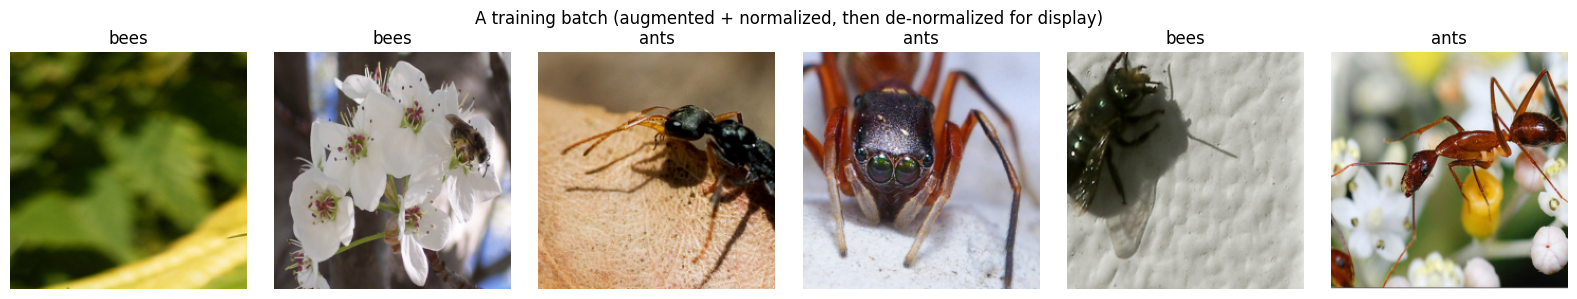

In [14]:
def denormalize(t):
    """Undo ImageNet normalization so we can display the image."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for i in range(6):
    axes[i].imshow(denormalize(imgs[i]).permute(1, 2, 0).numpy())
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis("off")
plt.suptitle("A training batch (augmented + normalized, then de-normalized for display)")
plt.tight_layout(); plt.show()


### 6.2 — Build the transfer-learning model

The recipe in three steps:
1. Load ResNet-18 **with pretrained ImageNet weights**.
2. **Freeze** all existing layers (`requires_grad = False`) — they're already
   good feature extractors.
3. **Replace** the final fully-connected layer (`model.fc`) with a fresh one
   sized for *our* number of classes. New layers are trainable by default.


In [15]:
# TODO 6.2 -- Build the transfer-learning model (feature-extraction mode).
#
# The recipe in three steps:
#   1. Load ResNet-18 WITH pretrained ImageNet weights
#      (weights=models.ResNet18_Weights.IMAGENET1K_V1).
#   2. FREEZE every existing parameter: loop over model.parameters() and set
#      param.requires_grad = False. They are already good feature extractors.
#   3. REPLACE the final fully-connected layer model.fc with a fresh
#      nn.Linear(num_features, len(class_names)). resnet18.fc maps 512 -> 1000;
#      we want 512 -> 2 (ants, bees). A freshly created layer is trainable
#      by default, so only the new head will learn.
#
# Hint: num_features = model.fc.in_features  gives you the 512.

# Step 1: TODO -- load resnet18 WITH pretrained weights
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Step 2: TODO -- freeze the backbone
for param in model.parameters():
    param.requires_grad = False

# Step 3: TODO -- replace the head with a fresh Linear sized for our classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

model = model.to(device)

# --- given: confirm only the new head is trainable ---
trainable = [n for n, p in model.named_parameters() if p.requires_grad]
print("Trainable parameters belong to:", trainable)
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Training {n_train:,} of {n_total:,} parameters "
      f"({100*n_train/n_total:.2f}%) -- the rest is frozen.")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\basil/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Trainable parameters belong to: ['fc.weight', 'fc.bias']
Training 1,026 of 11,177,538 parameters (0.01%) -- the rest is frozen.


### 6.3 — The training loop

This is the **canonical PyTorch training loop**. Memorize its shape — you'll
write it in every project:

```
for each epoch:
    model.train()
    for each batch:
        optimizer.zero_grad()      # clear old gradients
        outputs = model(inputs)    # forward pass
        loss = criterion(...)      # compute loss
        loss.backward()            # backprop -> gradients
        optimizer.step()           # update weights
    model.eval()
    ... evaluate on validation, no gradients ...
```


In [16]:
# TODO 6.3 -- Write the canonical PyTorch training loop.
#
# This is the loop you will write in EVERY project. Complete run_epoch.
#
# Inside the batch loop, when train_mode is True, the five steps are:
#   optimizer.zero_grad()      # clear old gradients
#   outputs = model(inputs)    # forward pass
#   loss = criterion(outputs, labels)
#   loss.backward()            # backprop -> gradients
#   optimizer.step()           # update weights
# When train_mode is False (validation): forward + loss only, NO zero_grad,
# NO backward, NO step. The `with torch.set_grad_enabled(train_mode)` block
# is given -- it turns autograd on for training and off for validation.
#
# Also remember: call model.train() at the start of a training epoch and
# model.eval() at the start of a validation epoch (this switches BatchNorm).

criterion = nn.CrossEntropyLoss()
# Only the head's parameters are passed to the optimizer.
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

def run_epoch(loader, train_mode):
    """Run one epoch. Returns (avg_loss, accuracy)."""
    # TODO: set the model to train() or eval() depending on train_mode
    model.train() if train_mode else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train_mode):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            # TODO: if train_mode, zero the gradients
            if train_mode:
                optimizer.zero_grad() 
            # TODO: forward pass -> outputs
            outputs = model(inputs)
            # TODO: compute the loss
            loss = criterion(outputs, labels)
            if train_mode:
                # TODO: backprop, then optimizer step
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * inputs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += inputs.size(0)
    return total_loss / total, correct / total

# --- given: the epoch loop + reporting ---
EPOCHS = 5
history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train_mode=True)
    va_loss, va_acc = run_epoch(val_loader,   train_mode=False)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    print(f"Epoch {epoch}/{EPOCHS}  "
          f"train loss {tr_loss:.3f} acc {tr_acc:.3f}  |  "
          f"val loss {va_loss:.3f} acc {va_acc:.3f}")
print("\nDone. With a frozen ImageNet backbone you should already be ~0.90+ val acc")
print("on only ~240 training images -- that is the power of transfer learning.")


Epoch 1/5  train loss 0.703 acc 0.549  |  val loss 0.593 acc 0.601
Epoch 2/5  train loss 0.552 acc 0.742  |  val loss 0.449 acc 0.850
Epoch 3/5  train loss 0.455 acc 0.811  |  val loss 0.344 acc 0.889
Epoch 4/5  train loss 0.369 acc 0.906  |  val loss 0.298 acc 0.922
Epoch 5/5  train loss 0.332 acc 0.881  |  val loss 0.267 acc 0.928

Done. With a frozen ImageNet backbone you should already be ~0.90+ val acc
on only ~240 training images -- that is the power of transfer learning.


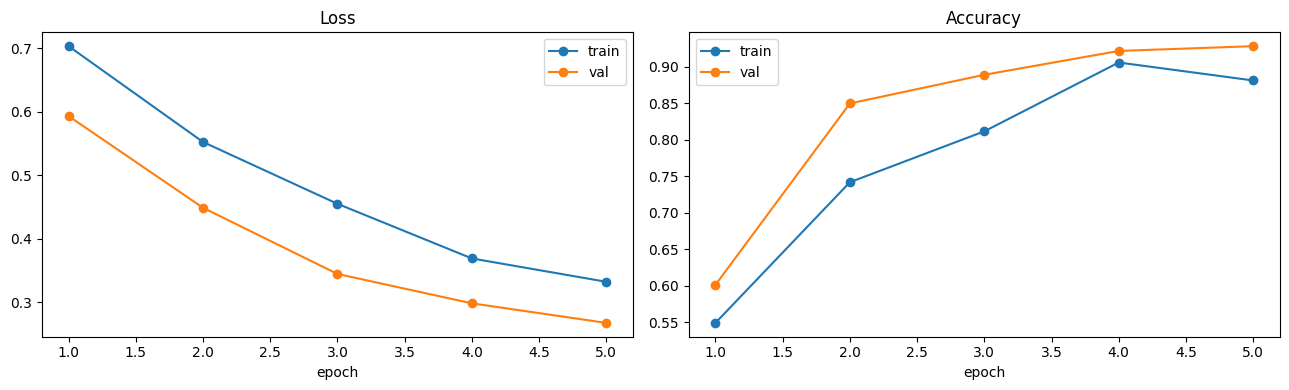

In [17]:
# Plot the learning curves -- always do this, it tells you a lot.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, EPOCHS + 1)
ax1.plot(ep, history["train_loss"], "o-", label="train")
ax1.plot(ep, history["val_loss"],   "o-", label="val")
ax1.set_title("Loss"); ax1.set_xlabel("epoch"); ax1.legend()
ax2.plot(ep, history["train_acc"], "o-", label="train")
ax2.plot(ep, history["val_acc"],   "o-", label="val")
ax2.set_title("Accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
plt.tight_layout(); plt.show()


### 6.4 — Inspect predictions

Always look at what the model actually predicts, including its confidence.


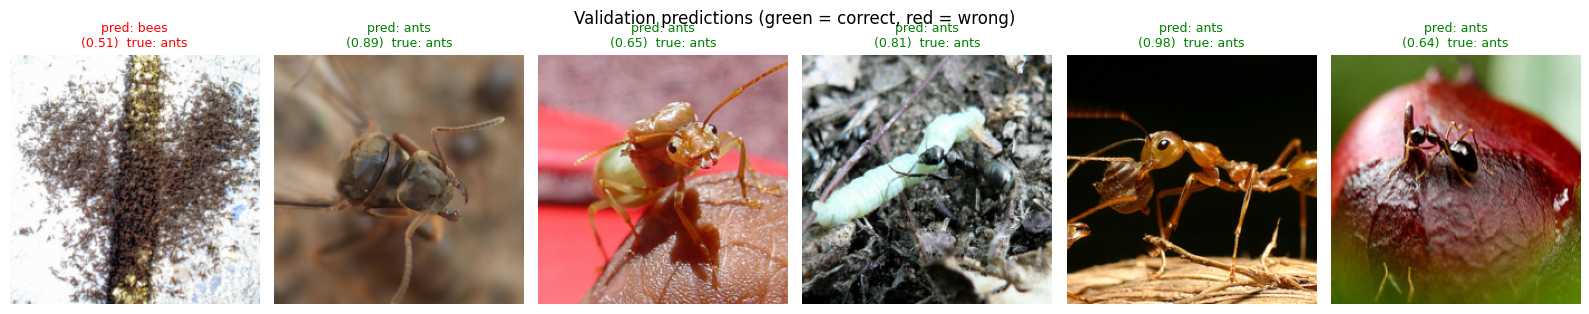

In [18]:
model.eval()
imgs, labels = next(iter(val_loader))
with torch.no_grad():
    probs = F.softmax(model(imgs.to(device)), dim=1).cpu()
preds = probs.argmax(1)

fig, axes = plt.subplots(1, 6, figsize=(16, 3.2))
for i in range(6):
    axes[i].imshow(denormalize(imgs[i]).permute(1, 2, 0).numpy())
    correct = preds[i] == labels[i]
    color = "green" if correct else "red"
    axes[i].set_title(f"pred: {class_names[preds[i]]}\n"
                      f"({probs[i, preds[i]]:.2f})  true: {class_names[labels[i]]}",
                      color=color, fontsize=9)
    axes[i].axis("off")
plt.suptitle("Validation predictions (green = correct, red = wrong)")
plt.tight_layout(); plt.show()


In [19]:
# TODO 6.4 -- Fine-tuning vs feature-extraction.
#
# Above you FROZE the whole backbone and trained only the head
# (feature extraction). Now do FINE-TUNING: unfreeze the last residual
# stage (layer4) and train it too, with a SMALLER learning rate so you do
# not destroy the good pretrained weights.
#
# Steps:
#   1. Reload a fresh pretrained ResNet-18.
#   2. Freeze EVERYTHING (requires_grad = False on every parameter).
#   3. Unfreeze layer4: set requires_grad = True for every parameter in
#      ft_model.layer4.parameters().
#   4. Replace ft_model.fc with a fresh nn.Linear sized for our classes
#      (a new layer is trainable by default).
#   5. Build an Adam optimizer over ONLY the trainable parameters, lr=1e-4.
#
# Then complete run_epoch_generic -- a reusable version of the training loop
# that takes the model / optimizer / criterion as ARGUMENTS (so it is not
# tied to the globals from TODO 6.3). It is used again for ViT in Section 8,
# so get it right. Same five training steps as run_epoch.

# 1) TODO: reload a fresh pretrained ResNet-18
ft_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2) TODO: freeze everything
for param in ft_model.parameters():
    param.requires_grad = False

# 3) TODO: unfreeze layer4
for param in ft_model.layer4.parameters():
    param.requires_grad = True

# 4) TODO: replace the head
ft_model.fc = nn.Linear(ft_model.fc.in_features, len(class_names))
ft_model = ft_model.to(device)

# 5) TODO: Adam over only the trainable params, lr=1e-4
trainable_params = [p for p in ft_model.parameters() if p.requires_grad]
ft_optimizer = torch.optim.Adam(trainable_params, lr=1e-4)
ft_criterion = nn.CrossEntropyLoss()

def run_epoch_generic(m, opt, crit, loader, train_mode):
    """Reusable epoch runner -- model/optimizer/criterion passed in."""
    # TODO: set m to train()/eval() based on train_mode
    m.train if train_mode else m.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train_mode):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            if train_mode:
                # TODO: zero gradients
                opt.zero_grad()
            # TODO: forward pass
            outputs = m(inputs)
            # TODO: compute loss
            loss = crit(outputs, labels)
            if train_mode:
                # TODO: backward + step
                loss.backward()
                opt.step()
            total_loss += loss.item() * inputs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += inputs.size(0)
    return total_loss / total, correct / total

# --- given: train 5 epochs ---
for epoch in range(1, 6):
    tr = run_epoch_generic(ft_model, ft_optimizer, ft_criterion, train_loader, True)
    va = run_epoch_generic(ft_model, ft_optimizer, ft_criterion, val_loader,  False)
    print(f"Epoch {epoch}/5  train acc {tr[1]:.3f}  |  val acc {va[1]:.3f}")

# TODO (written answer): compare this final validation accuracy to TODO 6.3.
# Did fine-tuning help here? Why might fine-tuning NOT help much on a dataset
# this small (~240 training images)? Write one or two sentences.
# Your answer:
# the finetuned model performed better than the feature-extraction model.
# however with only small amount of data the model might overfit the training data and not generalize well to unseen data. 


Epoch 1/5  train acc 0.762  |  val acc 0.895
Epoch 2/5  train acc 0.914  |  val acc 0.922
Epoch 3/5  train acc 0.951  |  val acc 0.928
Epoch 4/5  train acc 0.943  |  val acc 0.889
Epoch 5/5  train acc 0.959  |  val acc 0.928


## 7 · Data augmentation pipelines

> *Lecture recap:* most CV tasks want more data. Augmentation makes "new" data
> from what you have: mirroring, random crops, rotation/shear, and **color
> shifting** (jitter the R/G/B channels — lighting changes the pixels but not
> the label). The golden rule: an augmentation is valid only if it **preserves
> the label**.

You already used `RandomResizedCrop` + `RandomHorizontalFlip` in Section 6.
Let's *see* what a fuller augmentation pipeline does to a single image — this is
exactly what `torchvision.transforms` is for, and it's what you'll use in real
projects.


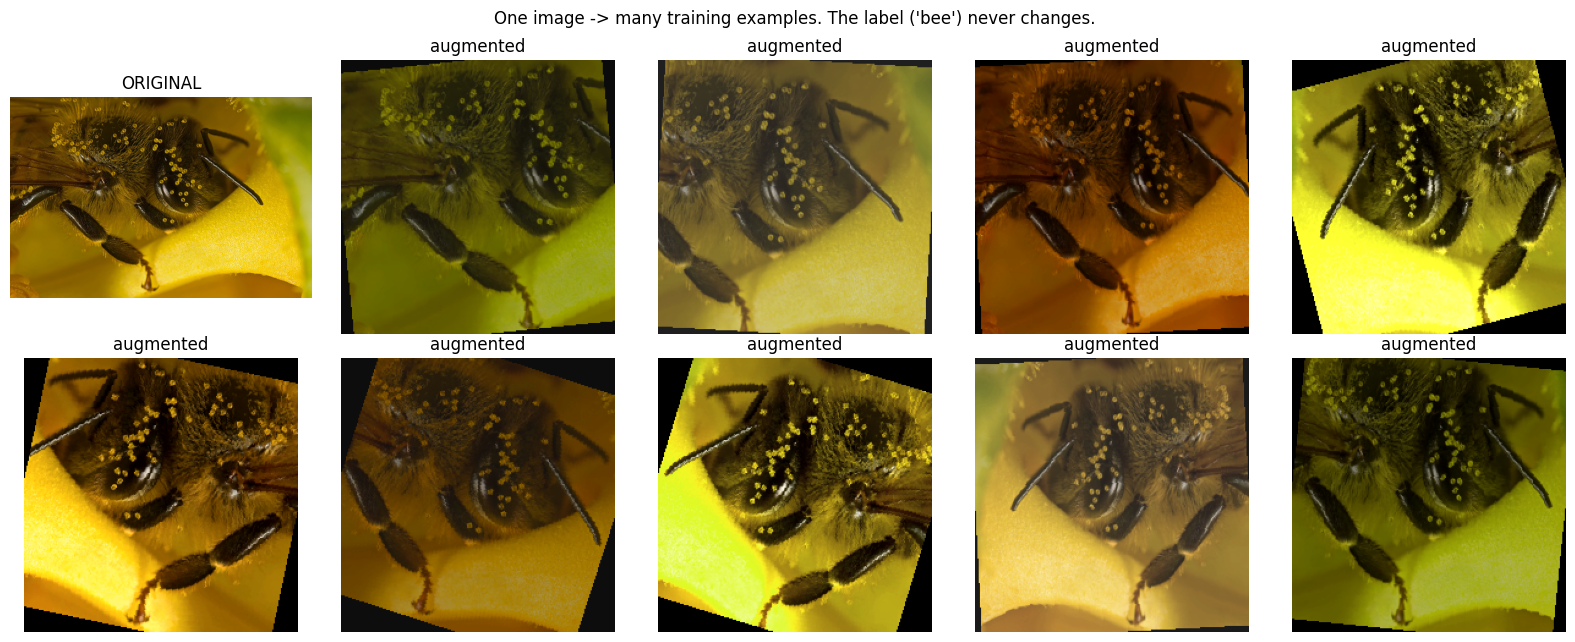

In [20]:
# TODO 7.1 -- Build a production-style augmentation pipeline.
#
# Complete the `augment` pipeline. It should chain these transforms
# (every call produces a different random result):
#   - transforms.RandomResizedCrop(224, scale=(0.6, 1.0))   random crop + zoom
#   - transforms.RandomHorizontalFlip(p=0.5)                mirror
#   - transforms.RandomRotation(degrees=20)                 small rotation
#   - transforms.ColorJitter(brightness=0.3, contrast=0.3,
#                            saturation=0.3, hue=0.05)      'color shifting'
# Pass them to transforms.Compose([...]).

from PIL import Image
import glob

# Grab one real training image to augment. (given)
sample_path = glob.glob(os.path.join(DATA_DIR, "train", "bees", "*"))[0]
original = Image.open(sample_path).convert("RGB")

augment = transforms.Compose([
   transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
   transforms.RandomHorizontalFlip(p=0.5),
   transforms.RandomRotation(degrees=20),
   transforms.ColorJitter(brightness=0.3, contrast=0.3,
						  saturation=0.3, hue=0.05),
])

# --- given: show one image -> many augmented versions ---
fig, axes = plt.subplots(2, 5, figsize=(16, 6.5))
axes[0, 0].imshow(original); axes[0, 0].set_title("ORIGINAL"); axes[0, 0].axis("off")
for ax in axes.flat[1:]:
    ax.imshow(augment(original))     # each call -> a new random augmentation
    ax.set_title("augmented"); ax.axis("off")
plt.suptitle("One image -> many training examples. The label ('bee') never changes.")
plt.tight_layout(); plt.show()


Each panel is the *same bee*, but to the network they're different inputs. That's free extra data, and it makes the model robust to camera angle, lighting, and framing.


In [21]:
# TODO 7.2 -- Label-safe augmentation for handwritten digits.
#
# One augmentation in the pipeline above is DANGEROUS for some tasks.
# RandomRotation(degrees=20) is fine for bees, but imagine a model that
# reads handwritten digits (LeNet's task).
#
# (a) Written answer: explain why a LARGE random rotation can BREAK the
#     label for digits, and name one augmentation that is ALWAYS safe for
#     natural-object photos.
# (b) Build `digit_safe_augment`: a conservative, label-preserving pipeline
#     you would actually use for MNIST-style 28x28 digit data. Suggested
#     transforms (all label-safe for digits):
#       - transforms.RandomRotation(degrees=10)        small only
#       - transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))  tiny shifts
#       - transforms.RandomResizedCrop(28, scale=(0.9, 1.0))        very mild crop
#     Deliberately include NO horizontal/vertical flip -- explain in a
#     comment why flips are unsafe for digits.

# (a) TODO written answer -- why is large rotation dangerous for digits, and
#     which augmentation is always safe for natural-object photos?
# Your answer:
# a high rotation can make a number like 6 look like 9 and a 2 look like 5 which might mislead the model.
# a safe for transformation would be the color jitter, because it only changes the color and doesnt change the structre of the image it self.

# (b) TODO: build the label-safe pipeline for digit data
digit_safe_augment = transforms.Compose([
	transforms.RandomRotation(degrees=10),
	transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
	transforms.RandomResizedCrop(28, scale=(0.9, 1.0)),
])
print("digit_safe_augment ready -- note: no flips, only small rotations.")


digit_safe_augment ready -- note: no flips, only small rotations.


## 8 · Vision Transformer (ViT) vs ResNet

> *Lecture recap:* CNNs have **high inductive bias** — locality, translation invariance, hierarchy. That bias helps with small data but limits the function space. The Vision Transformer drops most of that bias: it cuts the image into patches and runs **self-attention** over them, so any patch can attend to any other patch **in a single step** (a CNN needs many layers to grow its receptive field). Attention also generalizes across modalities (text, image, audio) — that is why Transformers took over.

In practice you **use** a pretrained ViT exactly like a pretrained ResNet — `torchvision` provides both. We will load each, classify the same image with both, and then fine-tune a ViT on the ants-vs-bees dataset.


In [23]:
# TODO 8.1 -- Load a pretrained ResNet-50 and a pretrained ViT-B/16.
#
# The weight ENUMS are given. Complete the loads:
#   - resnet50: models.resnet50(weights=resnet_w)
#   - vit:      models.vit_b_16(weights=vit_w)
# Put each in eval() mode and move it to `device`  (chain .eval().to(device)).
#
# Each pretrained weight bundle ships with its OWN correct preprocessing --
# get it by calling weights.transforms(). Use it; don't hand-roll it.

resnet_w = models.ResNet50_Weights.IMAGENET1K_V2
vit_w    = models.ViT_B_16_Weights.IMAGENET1K_V1

# TODO: load each model WITH its pretrained weights, eval mode, on device
resnet50 = models.resnet50(weights=resnet_w).eval().to(device)
vit      = models.vit_b_16(weights=vit_w).eval().to(device)

# TODO: get each model's own preprocessing transform
resnet_pre = resnet_w.transforms()
vit_pre    = vit_w.transforms()
imagenet_categories = resnet_w.meta["categories"]

# --- given: report ---
print("ResNet-50 params:", f"{sum(p.numel() for p in resnet50.parameters()):,}")
print("ViT-B/16  params:", f"{sum(p.numel() for p in vit.parameters()):,}")
print("ViT patch size  : 16x16  -> a 224x224 image becomes 14x14 = 196 patches")


ResNet-50 params: 25,557,032
ViT-B/16  params: 86,567,656
ViT patch size  : 16x16  -> a 224x224 image becomes 14x14 = 196 patches


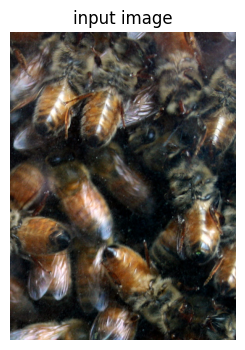

ResNet-50 says: bee                       (0.201)
ViT-B/16  says: apiary                    (0.586)

Both are ImageNet models, so expect a fine-grained label like a bee/insect species.


In [24]:
# TODO 8.2 -- Classify one image with BOTH models and compare.
#
# Complete the `top1` helper. Given a model, its preprocessing transform,
# and a PIL image, it should:
#   1. preprocess the PIL image, add a batch dim with .unsqueeze(0), move
#      it to `device`
#   2. under torch.no_grad(), run the model and softmax the logits over
#      dim=1, take row [0], move to .cpu()
#   3. find the argmax index, and return
#      (imagenet_categories[idx], probs[idx].item())

# Reuse a bee image from the dataset we already downloaded. (given)
img_path = glob.glob(os.path.join(DATA_DIR, "val", "bees", "*"))[0]
pil_img = Image.open(img_path).convert("RGB")

def top1(model, preprocess, pil):
    image = preprocess(pil).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.softmax(model(image), dim=1)[0].cpu()
    idx = prob.argmax().item()   
    return imagenet_categories[idx], prob[idx].item()

# --- given: run both and display ---
r_label, r_conf = top1(resnet50, resnet_pre, pil_img)
v_label, v_conf = top1(vit,      vit_pre,    pil_img)

plt.figure(figsize=(4, 4)); plt.imshow(pil_img); plt.axis("off")
plt.title("input image"); plt.show()
print(f"ResNet-50 says: {r_label:25s} ({r_conf:.3f})")
print(f"ViT-B/16  says: {v_label:25s} ({v_conf:.3f})")
print("\nBoth are ImageNet models, so expect a fine-grained label like a bee/insect species.")


### 8.1 — Find the ViT classification head

Before fine-tuning a ViT you need to know *what its final layer is called*. For ResNet it was `model.fc`; for `vit_b_16` it is something else. Run the cell below and **scroll to the very bottom** of the printout to find the classification head.

In [25]:
# Exploration cell -- run it and read the LAST lines of the output.
# What is the name of the ViT's final classification layer?
vit_explore = models.vit_b_16(weights="IMAGENET1K_V1")
print(vit_explore)


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine

**Hint:** the ViT classification head is `vit.heads.head` — `heads` is a container module, and `head` is the final `Linear` classifier inside it. That is the layer you replace when fine-tuning, just like `model.fc` for ResNet.

Trainable ViT parameters belong to: ['heads.head.weight', 'heads.head.bias']
Training 1,538 of 85,800,194 ViT parameters (0.00%) -- the rest is frozen.

Starting ViT fine-tuning...
Epoch 1/5 ViT train loss 0.340 acc 0.902  |  val loss 0.129 acc 0.987
Epoch 2/5 ViT train loss 0.112 acc 0.984  |  val loss 0.059 acc 0.987
Epoch 3/5 ViT train loss 0.070 acc 0.988  |  val loss 0.041 acc 0.987
Epoch 4/5 ViT train loss 0.044 acc 0.988  |  val loss 0.035 acc 0.987
Epoch 5/5 ViT train loss 0.058 acc 0.975  |  val loss 0.032 acc 0.987

ViT fine-tuning complete.


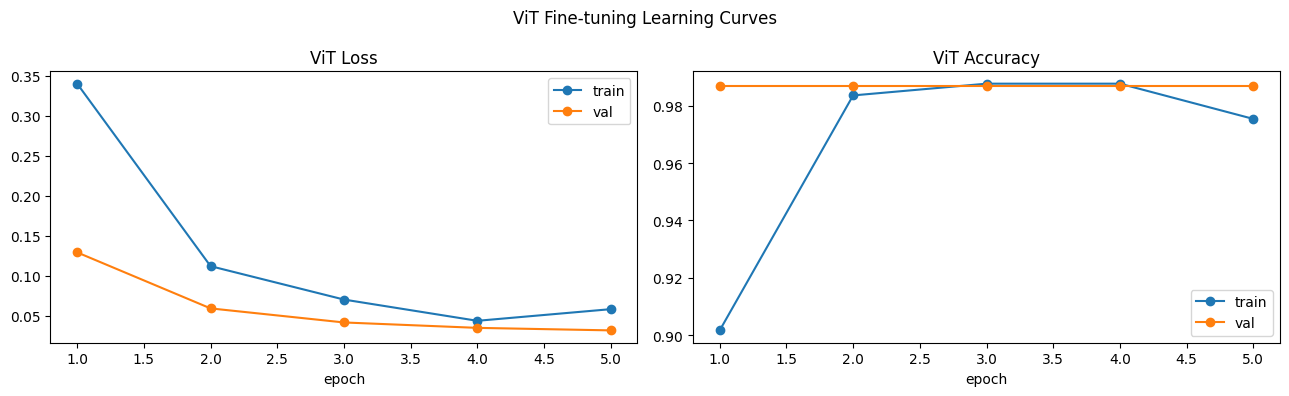

In [29]:
# TODO 8.3 -- Fine-tune a ViT on the ants-vs-bees dataset.
#
# Same feature-extraction recipe as the ResNet in TODO 6.2, but for a ViT.
# The ViT classification head is ft_vit_model.heads.head (see the hint above),
# and ViT-B/16's head has 768 in_features.
#
# Steps:
#   1. Load vit_b_16 WITH pretrained weights
#      (models.ViT_B_16_Weights.IMAGENET1K_V1).
#   2. Freeze EVERY parameter (requires_grad = False).
#   3. Replace ft_vit_model.heads.head with a fresh
#      nn.Linear(num_features_vit, len(class_names)).
#      Get num_features_vit from ft_vit_model.heads.head.in_features.
#   4. Build an Adam optimizer over ONLY the new head's parameters
#      (ft_vit_model.heads.head.parameters()), lr=1e-3.
#
# Then train for EPOCHS epochs using run_epoch_generic from TODO 6.4
# (already defined in the global scope -- do not redefine it).

# 1) TODO: load vit_b_16 with pretrained weights
ft_vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# 2) TODO: freeze everything
for param in ft_vit_model.parameters():
    param.requires_grad = False


# 3) TODO: replace the classification head
num_features_vit = ft_vit_model.heads.head.in_features
ft_vit_model.heads.head = nn.Linear(num_features_vit, len(class_names))
ft_vit_model = ft_vit_model.to(device)

# --- given: confirm only the new head is trainable ---
trainable_vit = [n for n, p in ft_vit_model.named_parameters() if p.requires_grad]
print("Trainable ViT parameters belong to:", trainable_vit)
n_train_vit = sum(p.numel() for p in ft_vit_model.parameters() if p.requires_grad)
n_total_vit = sum(p.numel() for p in ft_vit_model.parameters())
print(f"Training {n_train_vit:,} of {n_total_vit:,} ViT parameters "
      f"({100*n_train_vit/n_total_vit:.2f}%) -- the rest is frozen.")

# 4) TODO: Adam over only the new head's parameters, lr=1e-3
ft_vit_optimizer = torch.optim.Adam(ft_vit_model.heads.parameters(), lr=1e-3)
ft_vit_criterion = nn.CrossEntropyLoss()

# --- given: training loop + learning curves ---
print("\nStarting ViT fine-tuning...")
vit_history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
for epoch in range(1, EPOCHS + 1):
    tr_loss_vit, tr_acc_vit = run_epoch_generic(
        ft_vit_model, ft_vit_optimizer, ft_vit_criterion, train_loader, True)
    va_loss_vit, va_acc_vit = run_epoch_generic(
        ft_vit_model, ft_vit_optimizer, ft_vit_criterion, val_loader, False)
    vit_history["train_acc"].append(tr_acc_vit);   vit_history["val_acc"].append(va_acc_vit)
    vit_history["train_loss"].append(tr_loss_vit); vit_history["val_loss"].append(va_loss_vit)
    print(f"Epoch {epoch}/{EPOCHS} ViT "
          f"train loss {tr_loss_vit:.3f} acc {tr_acc_vit:.3f}  |  "
          f"val loss {va_loss_vit:.3f} acc {va_acc_vit:.3f}")
print("\nViT fine-tuning complete.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, EPOCHS + 1)
ax1.plot(ep, vit_history["train_loss"], "o-", label="train")
ax1.plot(ep, vit_history["val_loss"],   "o-", label="val")
ax1.set_title("ViT Loss"); ax1.set_xlabel("epoch"); ax1.legend()
ax2.plot(ep, vit_history["train_acc"], "o-", label="train")
ax2.plot(ep, vit_history["val_acc"],   "o-", label="val")
ax2.set_title("ViT Accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
plt.suptitle("ViT Fine-tuning Learning Curves")
plt.tight_layout(); plt.show()


---

# Part Two — CLIP & Multimodal Learning

The sections above covered CNNs and Vision Transformers — models that map an image to a fixed set of classes. The rest of this notebook covers **CLIP**, a model that connects images and *language*, which removes the fixed-class-list constraint entirely.


## 9 · CLIP setup

CLIP needs HuggingFace's `transformers` library. The cell below imports it and (re)confirms the device. The core scientific imports (`torch`, `nn`, `F`, `matplotlib`) were already set up in Section 1, so this is just the CLIP-specific add-on — read it and run it, nothing to fill in.


In [30]:
# Uncomment on a fresh environment:
# !pip install torch torchvision transformers pillow matplotlib --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import models, transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import io, urllib.request, os

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch :", torch.__version__)
print("device  :", device)

PyTorch : 2.12.0+cu130
device  : cuda


## 10 · CLIP zero-shot classification

> *Lecture recap:* **CLIP** (Contrastive Language-Image Pre-training, OpenAI
> 2021) is trained on 400M (image, text) pairs from the internet. It has two
> encoders — one for images, one for text — that both produce vectors in the
> **same embedding space**. To classify a new image, you don't retrain
> anything: you embed the image, embed each candidate class as a text prompt
> ("a photo of a {class}"), and pick the class whose text embedding is most
> similar (highest cosine similarity).
> This is **zero-shot classification** — you can recognize classes the model
> was never explicitly trained on. The class list becomes a *prompt at
> inference time*, not a fixed training-time decision.

In practice CLIP is the most-used model for: image search, content moderation,
zero-shot tagging, and as a backbone inside diffusion models (Stable
Diffusion's text encoder is a CLIP variant). Let's run it.


In [32]:
# We use HuggingFace's transformers library -- the standard CLIP interface
# in industry. First time: downloads ~600 MB of weights.
from transformers import CLIPModel, CLIPProcessor

MODEL_ID = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(MODEL_ID).to(device).eval()
processor  = CLIPProcessor.from_pretrained(MODEL_ID)

print(f"CLIP loaded: {MODEL_ID}")
print(f"image encoder params: {sum(p.numel() for p in clip_model.vision_model.parameters()):,}")
print(f"text  encoder params: {sum(p.numel() for p in clip_model.text_model.parameters()):,}")
print(f"shared embedding dim: {clip_model.config.projection_dim}")


d:\anaconda\envs\cv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\anaconda\envs\cv\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\basil\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this arti

CLIP loaded: openai/clip-vit-base-patch32
image encoder params: 87,456,000
text  encoder params: 63,165,952
shared embedding dim: 512


### 10.1 — Zero-shot classification on a real image

We'll classify a single image among a list of candidate classes — none of
which CLIP was specifically trained on as "classes". CLIP just compares the
image to each class's text embedding.


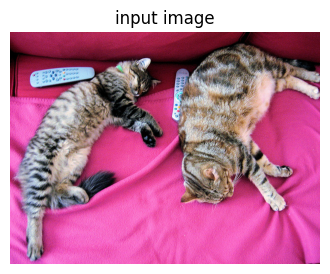


class                               | prob
--------------------------------------------------
a photo of a cat                    | 0.990  #############################
a photo of a dog                    | 0.005  
a photo of a horse                  | 0.002  
a photo of a bird                   | 0.001  
a photo of a car                    | 0.002  


In [33]:
# TODO 10.1 -- Run CLIP zero-shot classification on one image.
#
# The image download and the candidate_labels list are given. Your job is
# the three lines of actual CLIP inference:
#
#   1. Build the inputs: call `processor(...)` with text=candidate_labels,
#      images=image, return_tensors="pt", padding=True -- then .to(device).
#      The processor builds BOTH the image tensor and the text tensors.
#   2. Under torch.no_grad(), run `clip_model(**inputs)` -> outputs.
#   3. outputs.logits_per_image has shape (num_images, num_texts) -- the
#      image-vs-text similarity matrix. Take .softmax(dim=-1), row [0],
#      move to .cpu().numpy() to get a probability per class.

import ssl
# --- given: fetch a sample image (two cats, from the COCO val set) ---
SAMPLE_URL = "https://images.cocodataset.org/val2017/000000039769.jpg"
SAMPLE_PATH = "sample_clip.jpg"
if not os.path.exists(SAMPLE_PATH):
    ctx = ssl._create_unverified_context()
    with urllib.request.urlopen(SAMPLE_URL, context=ctx) as resp:
        with open(SAMPLE_PATH, "wb") as f:
            f.write(resp.read())
image = Image.open(SAMPLE_PATH).convert("RGB")

# The class list -- defined HERE at inference time, not during training.
candidate_labels = [
    "a photo of a cat",
    "a photo of a dog",
    "a photo of a horse",
    "a photo of a bird",
    "a photo of a car",
]

# 1) TODO: build the inputs with the processor, move to device
inputs = processor(text=candidate_labels, images=image, return_tensors="pt", padding=True).to(device)

# 2) TODO: run the model under no_grad
with torch.no_grad():
    outputs = clip_model(**inputs)

# 3) TODO: turn logits_per_image into a probability array `probs`
probs = outputs.logits_per_image.softmax(dim=-1)[0].cpu().numpy()

# --- given: display ---
plt.figure(figsize=(4, 4)); plt.imshow(image); plt.axis("off")
plt.title("input image"); plt.show()
print(f"\n{'class':35s} | prob")
print("-" * 50)
for label, p in zip(candidate_labels, probs):
    bar = "#" * int(p * 30)
    print(f"{label:35s} | {p:.3f}  {bar}")


### 10.2 — Same image, different class list

The point of zero-shot is that the class list is *yours*. Want fine-grained
breeds? Add them. Want to ask if it's indoors vs outdoors? Ask. No retraining.


In [34]:
# TODO 10.2 -- Show that the class list is yours to choose.
#
# For each `class_list` below, you must: turn the raw class strings into
# prompts, run CLIP, and find the top class. Fill in the two TODO lines.
#
#   prompts: wrap each class c as f"a photo of {c}"
#   probs  : same three-step inference as TODO 10.1
#            (processor -> clip_model -> logits_per_image.softmax)

for class_list in [
    ["indoor scene", "outdoor scene"],
    ["a kitten", "an adult cat", "an elderly cat"],
    ["one cat", "two cats", "three cats", "no cats at all"],
    ["a happy pet", "a sleeping pet", "a hungry pet", "a curious pet"],
]:
    # TODO: build the prompt list from class_list
    prompts = [f"a photo of {c}" for c in class_list]

    # TODO: run inference -> probs
    inputs = processor(text=prompts, images=image, return_tensors="pt",
                       padding=True).to(device)
    with torch.no_grad():
        probs = clip_model(**inputs).logits_per_image.softmax(dim=-1)[0].cpu().numpy()
    # --- given: report ---
    top_i = probs.argmax()
    print(f"prompt set: {class_list}")
    print(f"  -> top: '{class_list[top_i]}' ({probs[top_i]:.2f})\n")


prompt set: ['indoor scene', 'outdoor scene']
  -> top: 'indoor scene' (0.99)

prompt set: ['a kitten', 'an adult cat', 'an elderly cat']
  -> top: 'an adult cat' (0.92)

prompt set: ['one cat', 'two cats', 'three cats', 'no cats at all']
  -> top: 'two cats' (0.73)

prompt set: ['a happy pet', 'a sleeping pet', 'a hungry pet', 'a curious pet']
  -> top: 'a sleeping pet' (0.87)



### TODO 10.3 — the "CLIP always picks something" failure mode

CLIP's softmax runs over *your* class list. If the true class isn't in the list, CLIP still assigns all the probability to *some* class — it just picks the least-wrong option. The next code cell asks you to demonstrate this and then fix it.

In [ ]:
# TODO 10.3 -- Demonstrate (then fix) the missing-true-class failure mode.
#
# The sample `image` contains cats.
#
# (a) Build `bad_list`: a class list of plausible-but-WRONG options that
#     deliberately does NOT contain 'cat' (e.g. dog / rabbit / hamster,
#     each wrapped as 'a photo of a ...'). Run CLIP and print the probs.
#     Observe that CLIP still confidently picks one wrong class.
#
# (b) Build `fixed_list` = bad_list PLUS a correct option ('a photo of a
#     cat') AND an escape hatch ('none of these'). Re-run and print.
#
# Use the same processor -> clip_model -> logits_per_image.softmax inference
# you wrote in TODO 10.1.

# (a) TODO: build a wrong-but-plausible class list (no 'cat')
bad_list = [
    "a photo of a dog",
    "a photo of a rabbit",
    "a photo of a hamster",
    "a photo of a guinea pig",
]
inputs = processor(text=bad_list, images=image, return_tensors="pt",
                   padding=True).to(device)
with torch.no_grad():
    probs = clip_model(**inputs).logits_per_image.softmax(dim=-1)[0].cpu().numpy()
print("With WRONG class list:")
for c, p in zip(bad_list, probs):
    print(f"  {c:35s} -> {p:.2f}")

# (b) Add the correct class and an escape hatch
fixed_list = bad_list + ["a photo of a cat", "none of these"]
inputs = processor(text=fixed_list, images=image, return_tensors="pt",
                   padding=True).to(device)
with torch.no_grad():
    probs = clip_model(**inputs).logits_per_image.softmax(dim=-1)[0].cpu().numpy()
print("\nWith escape hatch:")
for c, p in zip(fixed_list, probs):
    print(f"  {c:35s} -> {p:.2f}")

# TODO (written answer): what is the new top prediction and its probability?
# Why is CLIP's confidence 'relative to your prompt set' rather than absolute?
# Your answer:
# clips confidence is relative because of softmax competition, it normalize score across candidates i provided.

With WRONG class list:
  a photo of a dog                    -> 0.42
  a photo of a rabbit                 -> 0.30
  a photo of a hamster                -> 0.11
  a photo of a guinea pig             -> 0.17

With escape hatch:
  a photo of a dog                    -> 0.00
  a photo of a rabbit                 -> 0.00
  a photo of a hamster                -> 0.00
  a photo of a guinea pig             -> 0.00
  a photo of a cat                    -> 0.96
  none of these                       -> 0.03


## 11 · CLIP's contrastive loss from scratch

> *Lecture recap:* CLIP is trained with a **symmetric contrastive loss**. Given
> a batch of N (image, text) pairs:
> 1. Encode each image → image embeddings `I` (N × d).
> 2. Encode each text → text embeddings `T` (N × d).
> 3. L2-normalize so all embeddings live on the unit sphere.
> 4. Compute the N×N similarity matrix `logits = I @ T.T * exp(t)`, where `t`
>    is a learned temperature.
> 5. The **diagonal** is the N correct pairings; the **off-diagonal** is the
>    N² − N wrong pairings.
> 6. **Cross-entropy** treating each row as a classifier over N text choices
>    (one of which is correct: the diagonal). Symmetrically: cross-entropy
>    over each column too (image direction). Average the two.

This is the **single most-influential loss function** in modern multimodal
learning. It's also short — about 10 lines. Worth seeing once.


In [36]:
# TODO 11.1 -- Implement CLIP's symmetric contrastive loss from scratch.
#
# This is the most influential loss in modern multimodal learning, and it
# is only a few lines. Follow the CLIP paper's pseudocode (Figure 3).
#
# Steps inside the function:
#   1. L2-normalize both embeddings so they live on the unit sphere
#      (then a dot product IS the cosine similarity).
#      Hint: F.normalize(x, p=2, dim=-1)
#   2. Similarity matrix, scaled by temperature:
#      logits_per_image = logit_scale * (img @ txt.t())   -> shape (N, N)
#      logits_per_text  = logits_per_image.t()            (symmetric)
#   3. The correct text for image i is column i -- so the targets are just
#      the indices [0, 1, ..., N-1].  Hint: torch.arange(N, device=...)
#   4. Symmetric cross-entropy: F.cross_entropy in BOTH directions
#      (image->text and text->image), then return the AVERAGE of the two.

def clip_contrastive_loss(image_embeds, text_embeds, logit_scale):
    """
    image_embeds: (N, d) unnormalized image features
    text_embeds : (N, d) unnormalized text features
    logit_scale : scalar exp(t), the learned temperature (~14.3 for OpenAI CLIP)
    Returns: scalar loss = average of image-direction and text-direction CE.
    """
    # 1) TODO: L2-normalize both sets of embeddings
    img = F.normalize(image_embeds, p=2, dim=-1)
    txt = F.normalize(text_embeds,  p=2, dim=-1)

    # 2) TODO: scaled similarity matrix, and its transpose
    logits_per_image = logit_scale * (img @ txt.t())
    logits_per_text  = logits_per_image.t()

    # 3) TODO: the correct-pair labels [0..N-1]
    N = img.size(0)
    labels = torch.arange(N, device=img.device)

    # 4) TODO: symmetric cross-entropy, averaged
    loss_i = F.cross_entropy(logits_per_image, labels)
    loss_t = F.cross_entropy(logits_per_text,  labels)
    return (loss_i + loss_t) / 2

# --- given: sanity checks ---
# With random embeddings the loss should be ~ ln(N) (pure random guessing).
N, d = 8, 64
rand_img = torch.randn(N, d)
rand_txt = torch.randn(N, d)
logit_scale = torch.tensor(np.log(1 / 0.07)).exp()       # ~14.3, OpenAI default

loss_random = clip_contrastive_loss(rand_img, rand_txt, logit_scale)
print(f"random pairs loss: {loss_random.item():.3f}  "
      f"(theoretical max for N={N}: {np.log(N):.3f})")

# With perfectly matched embeddings (image_i == text_i) the loss -> ~0.
matched = torch.randn(N, d)
loss_perfect = clip_contrastive_loss(matched, matched, logit_scale)
print(f"perfect pairs loss: {loss_perfect.item():.6f}  (should be near 0)")


random pairs loss: 3.181  (theoretical max for N=8: 2.079)
perfect pairs loss: 0.000009  (should be near 0)


### 11.2 — Train a toy CLIP-like alignment

Let's actually optimize this loss on a synthetic problem to see it *work*.
We'll generate random image-text pair "embeddings" with shared latent
structure, then train two tiny linear projection layers to align them — which
is *exactly* what CLIP's projection matrices (`W_i`, `W_t` in the paper's
pseudocode) do.


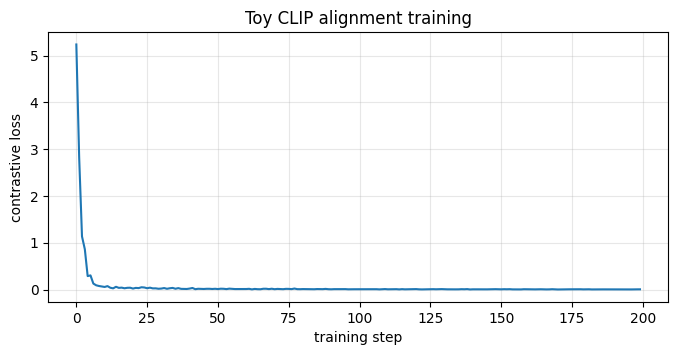

final loss: 0.0046  (started at ~5.2373)
learned temperature exp(t) = 15.61


In [37]:
# TODO 11.2 -- Train a toy CLIP-like alignment with your loss.
#
# The synthetic data and the two learnable projection matrices W_i, W_t are
# given. Your job is the training-step body inside the loop -- the same
# canonical pattern you wrote in Section 6, now with your contrastive loss:
#
#   img_emb = W_i(img_batch)                  # project image features
#   txt_emb = W_t(txt_batch)                  # project text features
#   loss = clip_contrastive_loss(img_emb, txt_emb, logit_scale.exp())
#   optimizer.zero_grad(); loss.backward(); optimizer.step()
# Note logit_scale is a learnable Parameter -- pass logit_scale.exp() to the
# loss (the loss expects exp(t), not t).

# --- given: synthetic paired data ---
torch.manual_seed(0)
N_TRAIN, LATENT_DIM = 200, 16
IMG_DIM, TXT_DIM, EMBED_DIM = 64, 48, 32

z = torch.randn(N_TRAIN, LATENT_DIM)                  # shared latent
A_img = torch.randn(LATENT_DIM, IMG_DIM)
A_txt = torch.randn(LATENT_DIM, TXT_DIM)
img_features = z @ A_img + 0.1 * torch.randn(N_TRAIN, IMG_DIM)
txt_features = z @ A_txt + 0.1 * torch.randn(N_TRAIN, TXT_DIM)

# --- given: learnable projections (CLIP's W_i, W_t) + learnable temperature ---
W_i = nn.Linear(IMG_DIM, EMBED_DIM, bias=False)
W_t = nn.Linear(TXT_DIM, EMBED_DIM, bias=False)
logit_scale = nn.Parameter(torch.tensor(np.log(1 / 0.07), dtype=torch.float32))

params = list(W_i.parameters()) + list(W_t.parameters()) + [logit_scale]
optimizer = torch.optim.Adam(params, lr=5e-3)

losses = []
for step in range(200):
    idx = torch.randperm(N_TRAIN)[:32]                # sample a batch
    img_batch = img_features[idx]
    txt_batch = txt_features[idx]

    # TODO: project both modalities into the shared space
    img_emb = W_i(img_batch)
    txt_emb = W_t(txt_batch)
    # TODO: compute the contrastive loss (pass logit_scale.exp())
    loss = clip_contrastive_loss(img_emb, txt_emb, logit_scale.exp())
    # TODO: zero gradients, backprop, optimizer step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# --- given: plot the loss curve ---
plt.figure(figsize=(8, 3.5))
plt.plot(losses)
plt.xlabel("training step"); plt.ylabel("contrastive loss")
plt.title("Toy CLIP alignment training")
plt.grid(alpha=0.3); plt.show()
print(f"final loss: {losses[-1]:.4f}  (started at ~{losses[0]:.4f})")
print(f"learned temperature exp(t) = {logit_scale.exp().item():.2f}")


retrieval@1 accuracy: 100.00%  (random would be 0.50%)


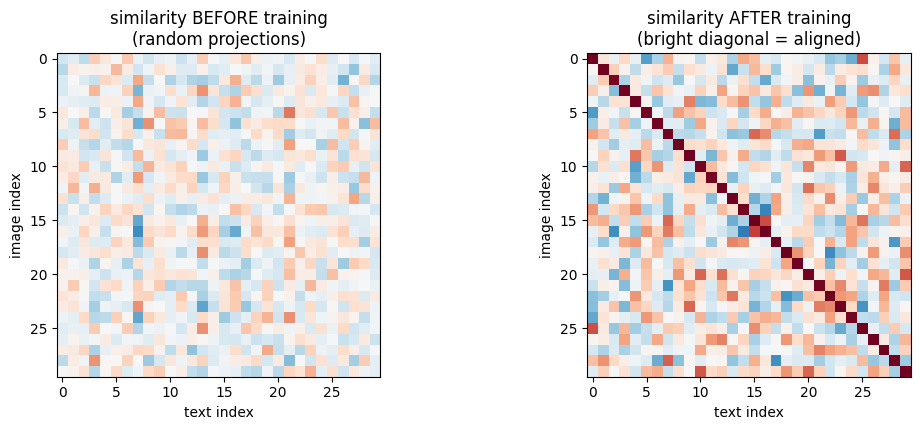

In [38]:
# TODO 11.3 -- Verify the trained projections actually align the modalities.
#
# After training, project ALL image and text features, normalize, and form
# the full (N, N) cosine-similarity matrix. A bright diagonal = good
# alignment (image i is most similar to text i).
#
# Fill in the three TODO lines:
#   img_aligned: F.normalize of W_i applied to ALL img_features, dim=-1
#   txt_aligned: F.normalize of W_t applied to ALL txt_features, dim=-1
#   similarity : img_aligned @ txt_aligned.t()      -> shape (N, N)

with torch.no_grad():
    img_aligned = F.normalize(W_i(img_features), dim=-1)
    txt_aligned = F.normalize(W_t(txt_features), dim=-1)
    similarity  = img_aligned @ txt_aligned.t()

# --- given: retrieval@1 accuracy ---
ranks = similarity.argmax(dim=1)
correct = (ranks == torch.arange(N_TRAIN)).float().mean()
print(f"retrieval@1 accuracy: {correct.item():.2%}  "
      f"(random would be {1/N_TRAIN:.2%})")

# --- given: visualize before vs after ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
W_i_rand = nn.Linear(IMG_DIM, EMBED_DIM, bias=False)
W_t_rand = nn.Linear(TXT_DIM, EMBED_DIM, bias=False)
with torch.no_grad():
    sim_before = F.normalize(W_i_rand(img_features), dim=-1) @ \
                 F.normalize(W_t_rand(txt_features), dim=-1).t()
axes[0].imshow(sim_before[:30, :30].numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_title("similarity BEFORE training\n(random projections)")
axes[1].imshow(similarity[:30, :30].numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_title("similarity AFTER training\n(bright diagonal = aligned)")
for ax in axes:
    ax.set_xlabel("text index"); ax.set_ylabel("image index")
plt.tight_layout(); plt.show()


## 12 · Prompt engineering & ensembling

> *Lecture recap:* CLIP's text encoder was trained on natural-language
> captions, not bare class names. The authors found that wrapping class names
> in a context phrase ("a photo of a {object}") consistently improves zero-shot
> accuracy. Using domain-specific templates ("a satellite photo of a
> {object}") helps more in specialised domains. **Ensembling** the
> predictions from many different prompt templates (the original paper used
> 80 prompts for ImageNet) improves accuracy by another ~3-5%.

This is real practical CLIP knowledge — the prompts are part of the model.


In [39]:
# TODO 12.1 -- Implement a reusable CLIP classify() helper.
#
# `classify` takes an image, a list of bare class names, and a prompt
# template string (with a '{}' placeholder), and returns softmax
# probabilities -- one per class.
#
# Inside the function:
#   1. Build `prompts` by formatting each class name into the template:
#      prompt_template.format(c) for each c in class_names
#   2. Run the same processor -> clip_model -> logits_per_image.softmax
#      inference from TODO 10.1; return the probabilities as a numpy array.

def classify(image, class_names, prompt_template="{}"):
    """Return softmax probabilities for each class given a prompt template."""
    # 1) TODO: build the prompt list from the template
    prompts = [prompt_template.format(c) for c in class_names]
    # 2) TODO: run CLIP and return probabilities (numpy array)
    inputs = processor(text=prompts, images=image, return_tensors="pt",
                       padding=True).to(device)
    with torch.no_grad():
        probs = clip_model(**inputs).logits_per_image.softmax(dim=-1)[0].cpu().numpy()
    return probs

# --- given: compare three templates ---
class_names = ["cat", "dog", "horse", "car", "bicycle"]

p_bare     = classify(image, class_names, "{}")
p_photo    = classify(image, class_names, "a photo of a {}")
p_specific = classify(image, class_names, "a close-up photo of a {}")

print(f"{'class':10s} | {'bare':>6s} | {'a photo of':>10s} | {'close-up photo':>15s}")
print("-" * 55)
for c, b, p, s in zip(class_names, p_bare, p_photo, p_specific):
    print(f"{c:10s} | {b:6.3f} | {p:10.3f} | {s:15.3f}")
print("\nNotice how the template changes both the winner AND the confidence.")


class      |   bare | a photo of |  close-up photo
-------------------------------------------------------
cat        |  0.967 |      0.989 |           0.977
dog        |  0.007 |      0.005 |           0.004
horse      |  0.006 |      0.002 |           0.005
car        |  0.013 |      0.002 |           0.010
bicycle    |  0.008 |      0.002 |           0.004

Notice how the template changes both the winner AND the confidence.


### 12.2 — Prompt ensembling

Now combine many prompts into one prediction. We average the **text
embeddings** (not the probabilities!) — that's what the original paper does,
because it gives a single ensembled embedding per class that can be cached.


In [42]:
# TODO 12.2 -- Implement prompt ensembling by averaging text embeddings.
#
# Instead of one prompt per class, use MANY templates and average their
# text embeddings into one 'centroid' embedding per class. The paper
# averages EMBEDDINGS (not probabilities) -- a centroid embedding can be
# cached and reused across many images.
#
# Fill in the TODO lines inside classify_ensemble:
#   - all_prompts: every (class, template) combination, formatted. Use a
#     nested comprehension: [t.format(c) for c in class_names for t in templates]
#   - image_emb / text_emb: pull the pooled embeddings out of the model
#     outputs via .pooler_output
#   - reshape text_emb to (num_classes, num_templates, dim) and .mean(dim=1)
#     to collapse the templates -> one embedding per class
#   - L2-normalize both, then logits = (image_emb @ text_emb.t()) * exp(temp)
#     where the temperature is clip_model.logit_scale.exp()

PROMPTS_ENSEMBLE = [
    "a photo of a {}.",
    "a photograph of a {}.",
    "a picture of a {}.",
    "a close-up photo of a {}.",
    "a bright photo of a {}.",
    "a low-resolution photo of a {}.",
    "a cropped photo of a {}.",
]

def classify_ensemble(image, class_names, templates):
    """Average text embeddings across templates, then classify."""
    # TODO: build all class x template prompt strings
    all_prompts = [t.format(c) for c in class_names for t in templates]

    inputs = processor(text=all_prompts, images=image, return_tensors="pt",
                       padding=True).to(device)
    with torch.no_grad():
        image_output = clip_model.get_image_features(
            pixel_values=inputs["pixel_values"])
        text_output = clip_model.get_text_features(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"])

    # TODO: extract the pooled embedding tensors (.pooler_output)
    image_emb = image_output.pooler_output
    text_emb  = text_output.pooler_output

    # TODO: reshape text_emb to (num_classes, num_templates, dim), mean over
    #       the templates axis -> one embedding per class
    text_emb = text_emb.reshape(len(class_names), len(templates), -1).mean(dim=1)

    # TODO: L2-normalize both, then scaled similarity -> softmax probs
    image_emb = F.normalize(image_emb, dim=-1)
    text_emb  = F.normalize(text_emb,  dim=-1)
    logits = (image_emb @ text_emb.t()) * clip_model.logit_scale.exp()
    return logits.softmax(dim=-1)[0].cpu().detach().numpy()

# --- given: compare single prompt vs ensemble ---
p_ensemble = classify_ensemble(image, class_names, PROMPTS_ENSEMBLE)

print(f"{'class':10s} | {'single':>7s} | {'7-prompt ensemble':>18s}")
print("-" * 45)
for c, single, ens in zip(class_names, p_photo, p_ensemble):
    print(f"{c:10s} | {single:7.3f} | {ens:18.3f}")


class      |  single |  7-prompt ensemble
---------------------------------------------
cat        |   0.989 |              0.992
dog        |   0.005 |              0.003
horse      |   0.002 |              0.001
car        |   0.002 |              0.003
bicycle    |   0.002 |              0.001


### TODO 12.3 — design prompts for a new task

Custom prompts matter most for *specialized* tasks. The next cell asks you to design and test prompt templates for an unusual zero-shot task: classifying photos as **indoor** vs **outdoor**.

In [ ]:
# TODO 12.3 -- Design and test three prompt templates for indoor vs outdoor.
#
# (a) Fill in `templates_to_test` with THREE different prompt templates for
#     an indoor-vs-outdoor classifier. Each must contain a '{}' placeholder.
#     Try to span a range: e.g. a bare '{}', a CLIP-friendly sentence
#     framing, and one more of your own design.
# (b) The loop runs each template through your classify() helper from
#     TODO 12.1 and reports the winner -- it is given.
# (c) Write a short note: which template was most confident and sensible,
#     and what makes a prompt good or bad for this task?

# (a) TODO: three templates, each containing '{}'
templates_to_test = [
    "{}",
    "a photo taken {}",
    "this is an {} photograph with visible surroundings",
]
class_names = ["indoor", "outdoor"]

# --- given: run each template ---
for t in templates_to_test:
    probs = classify(image, class_names, t)
    winner = class_names[probs.argmax()]
    print(f"template: {t!r}")
    print(f"  -> top: '{winner}' with prob {probs.max():.2f}\n")

# (c) TODO (written answer): which template was best, and what makes a
#     prompt good or bad here? (Hint: CLIP was trained on sentence-style
#     captions, not bare words.)
# Your answer:
# the sentence "A photo taken {}" will always be better than "{}" in both correctness and confidence, bare templates fails because indoor and outdoor as isolated tokens appear rarely in clips training captions.

template: '{}'
  -> top: 'indoor' with prob 0.89

template: 'a photo taken {}'
  -> top: 'indoor' with prob 0.94

template: 'this is an {} photograph with visible surroundings'
  -> top: 'indoor' with prob 0.99

